<a href="https://colab.research.google.com/github/zaporozhetsalena/MidTerm-Project.-Metrocar-Data-Analysis/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22HW_11_4_%D0%86%D0%BD%D1%82%D0%B5%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Plotly_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Інтерактивні візуалізації з Plotly

## Опис завдання
У цьому домашньому завданні ви будете створювати інтерактивні візуалізації з допомогою бібліотеки Plotly. Ви дізнаєтесь різницю між Plotly Express (швидкі графіки) та Graph Objects (повний контроль), та створите інтерактивний дашборд.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---

🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Завантаження даних
df = pd.read_csv("/content/drive/MyDrive/hometasks/yulu_rental.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Для plotly краще не встановлювати datetime як індекс
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Додаємо назви кварталів в окрему колонку
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['quarter_name'] = df['season'].map(quarter_map)

In [10]:
season_map = {
    12: 1, 1: 1, 2: 1,   # Winter
    3: 2, 4: 2, 5: 2,    # Summer
    6: 3, 7: 3, 8: 3, 9: 3,  # Monsoon
    10: 4, 11: 4         # Post-Monsoon
}

df['weather_season_india'] = df['month'].map(season_map)

## Завдання 1: Базовий інтерактивний лінійний графік (Plotly Express)

**Завдання:**
Створіть інтерактивний лінійний графік динаміки оренди за часом (рівень деталізації - як в даних) з можливістю zoom та hover.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яка перевага інтерактивного графіка над статичним?
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?


In [16]:
df = df.reset_index()  # якщо datetime був індексом

fig = px.line(
    df,
    x='datetime',
    y='count',
    title="Інтерактивний графік оренди"
)

fig.update_traces(line_width=2)

fig.update_layout(
    hovermode="x unified",
    template="plotly_white",
    height=500
)

## Завдання 2: Scatter plot з додатковими даними (Plotly Express)

**Завдання:**
Створіть scatter plot кількості орендованих велосипедів випадковими користувачами vs кількості орендованих велосипедів зареєстрованими користувачами. Розмір точок встановіть за сумарною кількістю велосипедів, які були взяті в оренду, а колір - за сезоном(кварталом). В hover_data - додайте деталі, які допоможуть вам в подальшому аналізі.

Дослідіть графік. Зверніть увагу, що ви можете вмикати і вимикати окремі квартали, якщо будете клікати на колір кварталу в легенді графіку.

**Дайте відповідь на питання.**
- Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?
- Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.

In [17]:
# якщо сезон = квартал (season)
fig = px.scatter(
    df,
    x='casual',
    y='registered',
    color='season',
    size='count',
    hover_data=['temp', 'humidity', 'windspeed', 'weather'],
    title="Casual vs Registered оренди велосипедів"
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

1. Чому є “дві лінії” (роздвоєність)?
 Це означає два різні типи користувачів:

Лінія 1:
багато registered
мало casual
регулярні користувачі (робота, щоденні поїздки)
Лінія 2:
більше casual
менше registered
випадкові користувачі (відпочинок, вихідні)
ІДЕЯ:
є два різних патерни поведінки користувачів
 Висновки для компанії:
1.сновний дохід дають registered користувачі
2. Casual користувачі залежать від сезону і погоди
3. Попит сильно зростає при поєднанні обох груп
треба планувати ресурси під сезонні піки

## Завдання 3: Порівняння Plotly Express vs Graph Objects

**Завдання:**
Створіть лінійний графік помісячної динаміки оренди (кількість оренд) велосипедів двома способами - з Plotly Express та з Graph Objects.

**Дайте відповіді на питання.**
1. Як ви розумієте основну різницю між цими двома підходами?
2. Коли краще використовувати Plotly Express?
3. Коли потрібен Graph Objects?


## Завдання 4 (Опціональне): Дашборд з make_subplots (Graph Objects)

**Завдання:**
Створіть дашборд з 4 різними графіками в одній фігурі:
- Bar chart - середні значення загальної кількості оренд велосипедів за сезонами(кварталами)
- Pie chart - відсоткове співвідношення погодних умов в даних
- Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
- Scatter plot - кореляція температури vs вологість

Додайте заголовок на дашборд.

**Дайте відповідь на питання**
- На ваш погляд, яка перевага об'єднання графіків в один дашборд?

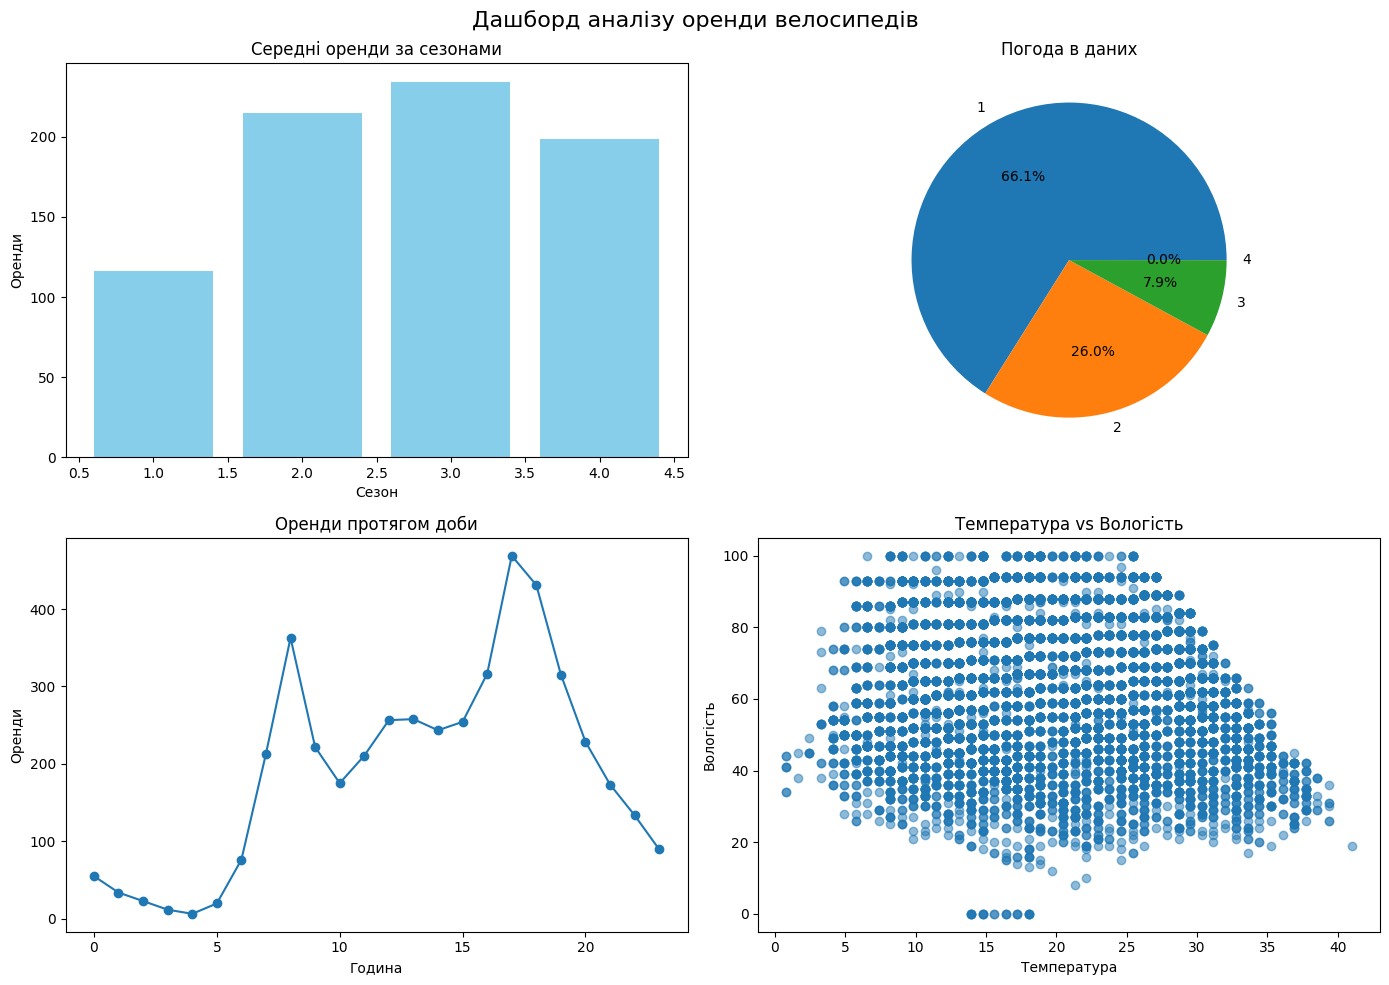

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# -------------------
# 1. Bar chart (сезони)
# -------------------
season_avg = df.groupby('season')['count'].mean()

ax[0,0].bar(season_avg.index, season_avg.values, color='skyblue')
ax[0,0].set_title("Середні оренди за сезонами")
ax[0,0].set_xlabel("Сезон")
ax[0,0].set_ylabel("Оренди")

# -------------------
# 2. Pie chart (погода)
# -------------------
weather_counts = df['weather'].value_counts()

ax[0,1].pie(
    weather_counts.values,
    labels=weather_counts.index,
    autopct='%1.1f%%'
)
ax[0,1].set_title("Погода в даних")

# -------------------
# 3. Line chart (години)
# -------------------
hour_avg = df.groupby('hour')['count'].mean()

ax[1,0].plot(hour_avg.index, hour_avg.values, marker='o')
ax[1,0].set_title("Оренди протягом доби")
ax[1,0].set_xlabel("Година")
ax[1,0].set_ylabel("Оренди")

# -------------------
# 4. Scatter (temp vs humidity)
# -------------------
ax[1,1].scatter(df['temp'], df['humidity'], alpha=0.5)
ax[1,1].set_title("Температура vs Вологість")
ax[1,1].set_xlabel("Температура")
ax[1,1].set_ylabel("Вологість")

# -------------------
# Загальний заголовок
# -------------------
fig.suptitle("Дашборд аналізу оренди велосипедів", fontsize=16)

plt.tight_layout()
plt.show()

На ваш погляд, яка перевага об'єднання графіків в один дашборд? -дуже зручно бачити динаміку в різних розрізах

## Завдання 5 (Опціональне): 3D візуалізація

**Завдання:**
Створіть 3D scatter plot для аналізу взаємозв'язку температури, швидкості вітру та загальної кількості орендованих велосипедів. Колір встановіть за сезоном(кварталом), а розмір - за загальною кількість оренд також.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?
2. Чи видно кластери в 3D просторі?
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?



In [26]:
import plotly.express as px

df_small = df.sample(200, random_state=42)

fig = px.scatter_3d(
    df_small,
    x='temp',
    y='windspeed',
    z='count',
    color='season',
    size='count',
    title="3D scatter (reduced data)"
)

fig.show()

Яку додаткову інформацію дає 3D візуалізація?
3D дозволяє побачити взаємозв’язок одразу трьох змінних
температура ↔ оренди
вітер ↔ оренди
температура + вітер разом впливають на попит


## Завдання 6: Експорт та збереження інтерактивних графіків

**Завдання:**
Збережіть побудований попередній графік на plotly в формат HTML. Також змініть вручну щось на графіку (зум, виділення частини графіку) і збережіть його як статичне зображення через іконку фотоапарату у формат PNG. Завантажте файли з графіком у HTML та PNG (або посилання на них на github) разом з посиланням на цей ноутбук при здачі ДЗ.


In [27]:
pip install --U kaleido


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --U


In [30]:
fig.write_html("bike_plot.html")